<a href="https://colab.research.google.com/github/selaluar/Arya-Pratama-Hendri_2411533008_ML2526/blob/main/Praktikum2/NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
dataset_url = "https://raw.githubusercontent.com/selaluar/Arya-Pratama-Hendri_2411533008_ML2526/main/Praktikum2/Breast_cancer_data.csv"
data = pd.read_csv(dataset_url)
data.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [4]:
def naive_bayes_gaussian(df, X, Y):
    features = list(df.columns)[:-1]
    prior = calculate_prior(df, Y)

    Y_pred = []
    for x in X:
        labels = sorted(list(df[Y].unique()))
        likelihood = [1] * len(labels)

        for j in range(len(labels)):
            for i in range(len(features)):
                likelihood[j] *= calculate_likelihood_gaussian(df, features[i], x[i], Y, labels[j])

        post_prob = [1] * len(labels)
        for j in range(len(labels)):
            post_prob[j] = likelihood[j] * prior[j]

        Y_pred.append(np.argmax(post_prob))

    return np.array(Y_pred)

In [7]:
from sklearn.model_selection import train_test_split

# Pastikan 'data' sudah ada (dataset sudah diload)
train, test = train_test_split(data, test_size=0.2, random_state=41)

In [10]:
from sklearn.naive_bayes import GaussianNB

X_train = train.drop(columns="diagnosis")
y_train = train["diagnosis"]

X_test = test.drop(columns="diagnosis")

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred_sklearn = gnb.predict(X_test)

In [11]:
def calculate_prior(df, Y):
    classes = sorted(list(df[Y].unique()))
    prior = []
    for c in classes:
        prior.append(len(df[df[Y] == c]) / len(df))
    return prior

In [12]:
import numpy as np

def calculate_likelihood_gaussian(df, feat_name, feat_val, Y, label):
    df_label = df[df[Y] == label]
    mean = df_label[feat_name].mean()
    std  = df_label[feat_name].std()

    # Hindari pembagian nol kalau std = 0 (jarang terjadi, tapi aman)
    if std == 0:
        std = 1e-9

    p_x_given_y = (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(-((feat_val - mean) ** 2 / (2 * std ** 2)))
    return p_x_given_y

In [13]:
def naive_bayes_gaussian(df, X, Y):
    features = list(df.columns)[:-1]   # semua fitur, kecuali label (kolom terakhir)
    labels = sorted(list(df[Y].unique()))
    prior = calculate_prior(df, Y)

    Y_pred = []
    for x in X:
        likelihood = [1] * len(labels)

        for j in range(len(labels)):
            for i in range(len(features)):
                likelihood[j] *= calculate_likelihood_gaussian(df, features[i], x[i], Y, labels[j])

        post_prob = [likelihood[j] * prior[j] for j in range(len(labels))]
        Y_pred.append(np.argmax(post_prob))

    return np.array(Y_pred)

MANUAL
Akurasi  = 0.9473684210526315
F1-Score = 0.96


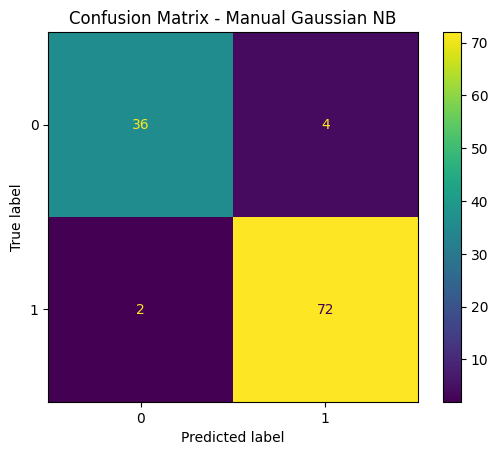

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

train, test = train_test_split(data, test_size=0.2, random_state=41)

X_test_manual = test.iloc[:, :-1].values
y_test = test.iloc[:, -1].values

y_pred_manual = naive_bayes_gaussian(train, X=X_test_manual, Y="diagnosis")

print("MANUAL")
print("Akurasi  =", accuracy_score(y_test, y_pred_manual))
print("F1-Score =", f1_score(y_test, y_pred_manual))

cm_manual = confusion_matrix(y_test, y_pred_manual)
ConfusionMatrixDisplay(confusion_matrix=cm_manual, display_labels=[0, 1]).plot()
plt.title("Confusion Matrix - Manual Gaussian NB")
plt.show()

SKLEARN
Akurasi  = 0.9473684210526315
F1-Score = 0.96


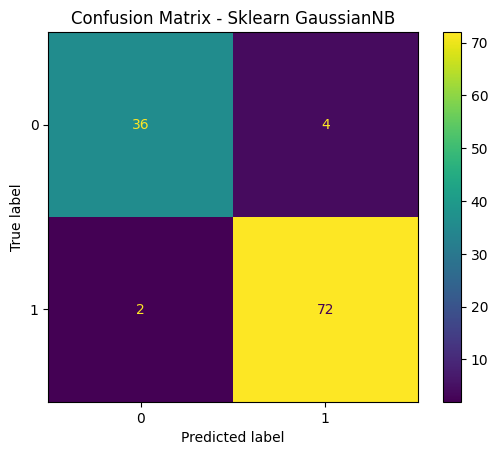

In [15]:
from sklearn.naive_bayes import GaussianNB

X_train = train.drop(columns="diagnosis")
y_train = train["diagnosis"]
X_test  = test.drop(columns="diagnosis")

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred_sklearn = gnb.predict(X_test)

print("SKLEARN")
print("Akurasi  =", accuracy_score(y_test, y_pred_sklearn))
print("F1-Score =", f1_score(y_test, y_pred_sklearn))

cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
ConfusionMatrixDisplay(confusion_matrix=cm_sklearn, display_labels=[0, 1]).plot()
plt.title("Confusion Matrix - Sklearn GaussianNB")
plt.show()

In [16]:
import pandas as pd

hasil = pd.DataFrame({
    "Model": ["Manual Gaussian NB", "Sklearn GaussianNB"],
    "Accuracy": [accuracy_score(y_test, y_pred_manual), accuracy_score(y_test, y_pred_sklearn)],
    "F1-Score": [f1_score(y_test, y_pred_manual), f1_score(y_test, y_pred_sklearn)]
})
hasil

,Model,Accuracy,F1-Score
0,Manual Gaussian NB,0.947368,0.96
1,Sklearn GaussianNB,0.947368,0.96
